# `fl_plot` demo — composable panels

`fl_plot` is the additive panel kit: small **marks** that draw one visual element, composed
into figures with `grid(...)` + `Row(...)`. Nothing in `fl_graphics` / `fl_visualization`
changed — this is the home for *new* figures, so notebooks compose instead of copying
figure functions between cells.

**Layers** (dependency strictly downward):

| layer | what | names |
|---|---|---|
| theme | style constants, one default matching the legacy look | `Theme`, `THEME` |
| axis | the categorical swept-axis rule (p → commas, n → plain) | `sweep_axis` |
| data | tidy frame → arrays | `rep_dists`, `summarize` |
| marks | draw onto an `ax`, return caption fragment + legend entry | `BoxDist`, `ViolinDist`, `Band`, `MeanCI`, `BandStack`, `QuantileBand`, `RefOverlay` |
| compose | rows × factor columns → finished figure | `Row`, `grid`, `save` |

**Data contract** — the standard tidy sweep frame: columns `n, p, j` plus whatever value
columns the marks reference, one row per (replicate, factor). Exactly what the cached
sweeps already are.

This demo renders everything from `nb_outputs/ex2v2_df_{p,n}.parquet` — no simulation runs.

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_plot import (THEME, Theme, grid, Row, save,
                     BandStack, Band, MeanCI, QuantileBand,
                     BoxDist, ViolinDist, RefOverlay,
                     sweep_axis, rep_dists, summarize)

OUT_DIR = REPO_ROOT / "nb_outputs" / "fl_plot_demo"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def show(fig):
    """Render inline without writing a file (fl_plot forces the Agg backend)."""
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


def load_sweep(name):
    df = pd.read_parquet(REPO_ROOT / "nb_outputs" / name)
    oos = df["measured_out_of_subspace"]
    sin2_in = (df["sin2_j"] - oos) / (1.0 - oos)          # in-subspace rotation (exact split)
    return df.assign(
        sin2_in=sin2_in,
        diff_in_rot=sin2_in - df["rotation"],             # …minus its factor-space limit
        oos_gap=oos - df["floor"],                        # out-of-subspace − floor
    )


df_p = load_sweep("ex2v2_df_p.parquet")   # growing p, fixed n=63
df_n = load_sweep("ex2v2_df_n.parquet")   # growing n, fixed p=3000
print(f"growing-p: {len(df_p):,} rows | growing-n: {len(df_n):,} rows")
print("columns:", ", ".join(df_p.columns))

growing-p: 18,000 rows | growing-n: 27,000 rows
columns: n, p, j, sin2_j, rhs, gap, floor, rotation, rho, theta_j_sample_eigenvalue, ell_bulk_eigenvalue_average, observable_floor_estimate, measured_out_of_subspace, measured_in_subspace, angle_in_subspace, rep, sin2_in, diff_in_rot, oos_gap


## 1 — One mark, one row

The smallest figure: per-replicate boxplots of the total gap at each swept value. `grid`
supplies the factor columns, shared axes, titles, grid lines, and assembles the caption
from the mark's own fragment.

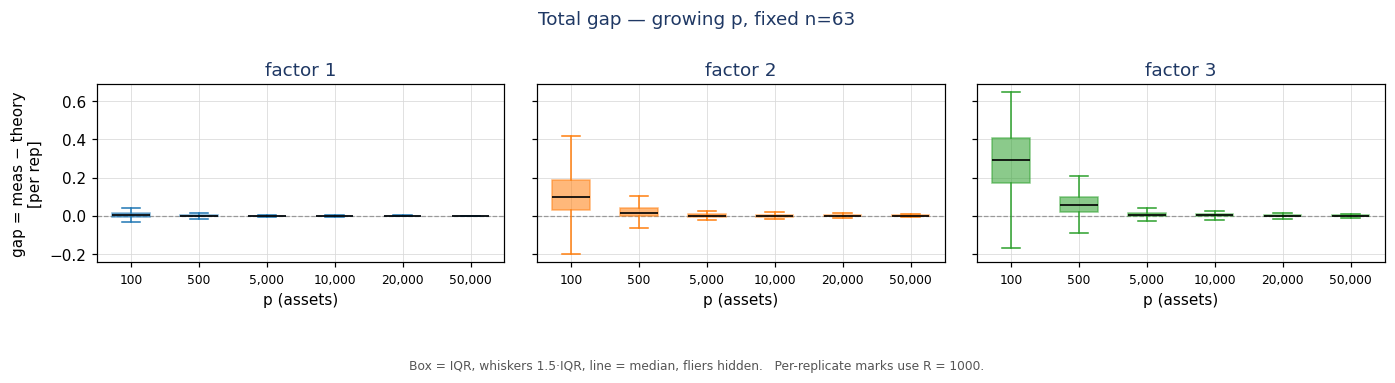

In [2]:
fig, _ = grid(df_p, "p",
              rows=[Row(BoxDist("gap"), ylabel="gap = meas − theory\n[per rep]")],
              suptitle="Total gap — growing p, fixed n=63")
show(fig)

## 2 — The box → violin swap is one word

Same figure on the growing-*n* sweep with `ViolinDist` — the swap that previously required
a parallel notebook. The caption updates itself because each mark carries its fragment.

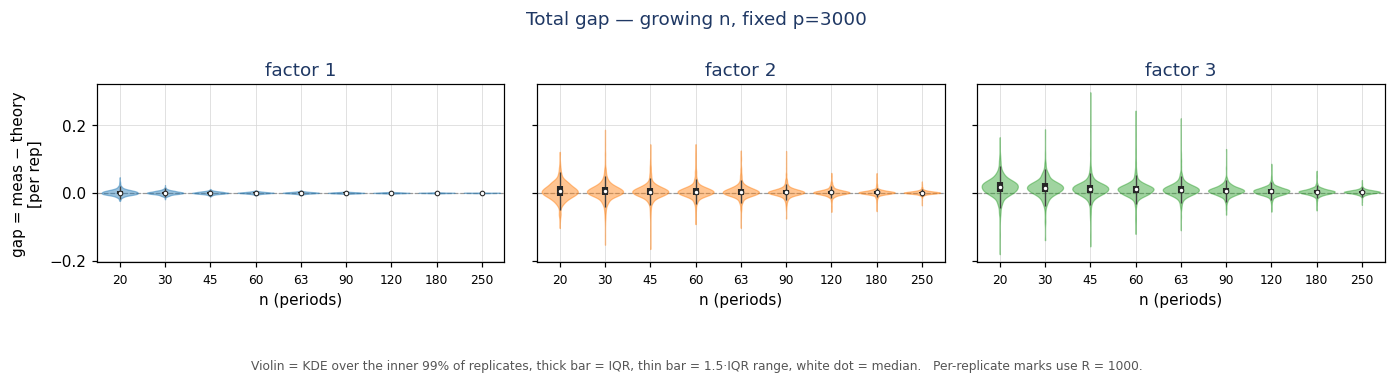

In [3]:
fig, _ = grid(df_n, "n",
              rows=[Row(ViolinDist("gap"), ylabel="gap = meas − theory\n[per rep]")],
              suptitle="Total gap — growing n, fixed p=3000")
show(fig)

## 3 — Layering marks in one row

A `Row` takes a *list* of marks drawn in order onto the same axes. Here the in-subspace
rotation distribution with the k×k rotation overlaid as a reference series
(median + Q1–Q3), `sharey=True` so all panels read on one scale.

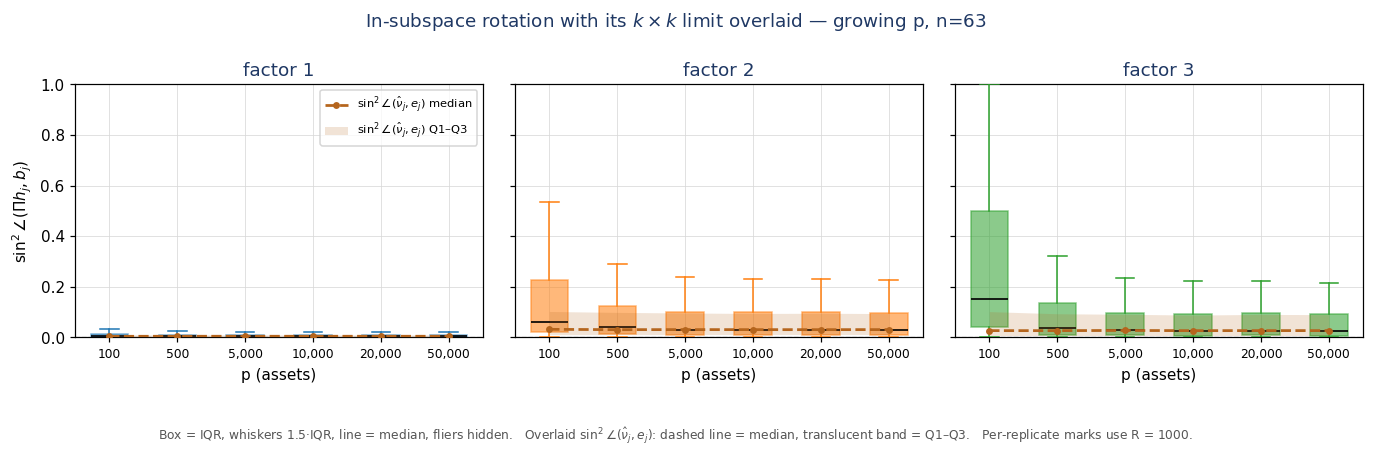

In [4]:
fig, _ = grid(df_p, "p",
              rows=[Row([BoxDist("sin2_in"),
                         RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j,e_j)$")],
                        ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
              sharey=True,
              suptitle=r"In-subspace rotation with its $k\times k$ limit overlaid — growing p, n=63")
show(fig)

## 4 — Measured vs theory: band + mean over a pathwise row

The two-row "settles onto the band" shape: theory limit as a `Band`, measured mean as
`MeanCI` riding on it, and the per-replicate difference below. This is the in-subspace
rotation against its factor-space limit.

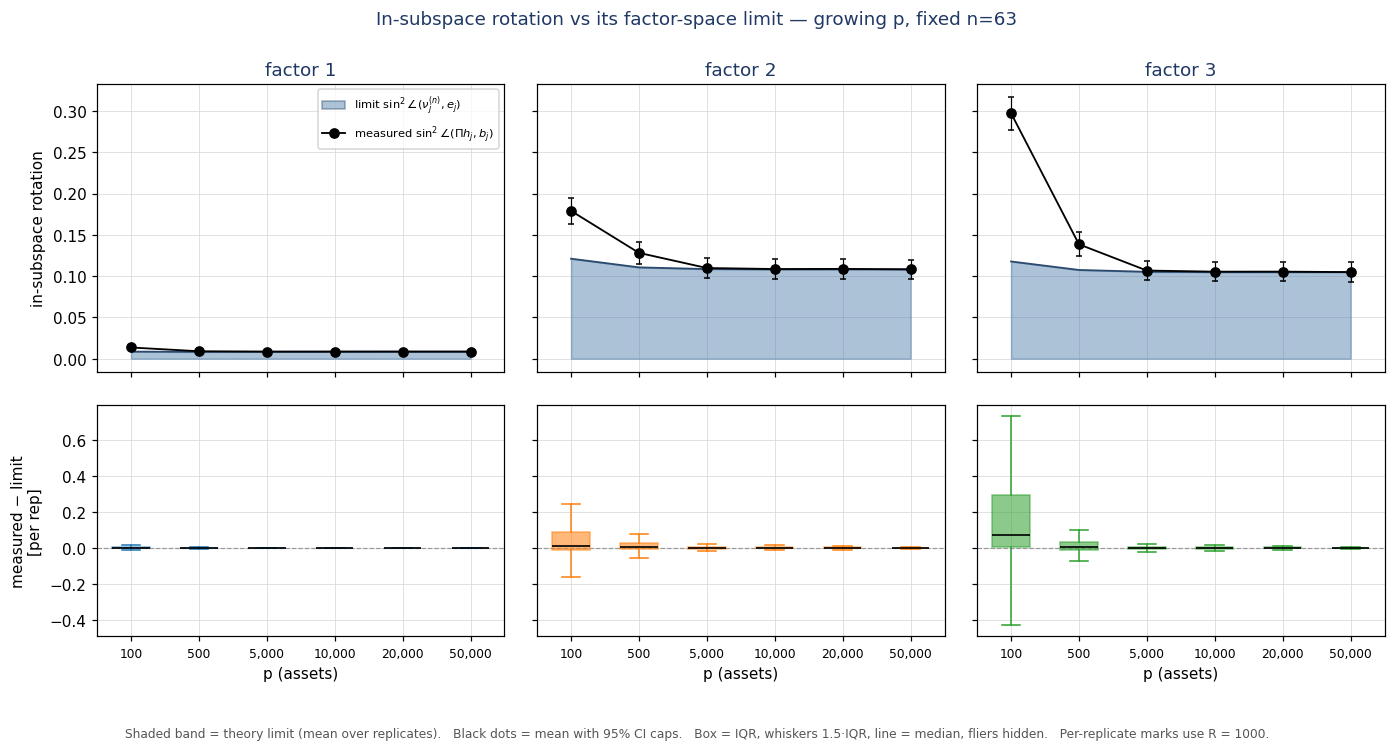

In [5]:
fig, _ = grid(df_p, "p",
              rows=[Row([Band("rotation", label=r"limit $\sin^2\angle(\nu^{(n)}_j, e_j)$"),
                         MeanCI("sin2_in", label=r"measured $\sin^2\angle(\Pi h_j, b_j)$")],
                        ylabel="in-subspace rotation", height=1.0),
                    Row(BoxDist("diff_in_rot"), ylabel="measured − limit\n[per rep]")],
              suptitle="In-subspace rotation vs its factor-space limit — growing p, fixed n=63")
show(fig)

## 5 — The band stack, and taller compositions

`BandStack` is the classic additive out-of-subspace + in-subspace decomposition with the
measured line. Rows compose freely — here a four-row figure mixing it with three pathwise
rows (`ylim`/`yticks` are per-`Row` options; `THEME.sin2_ticks` is the standard sin² axis).

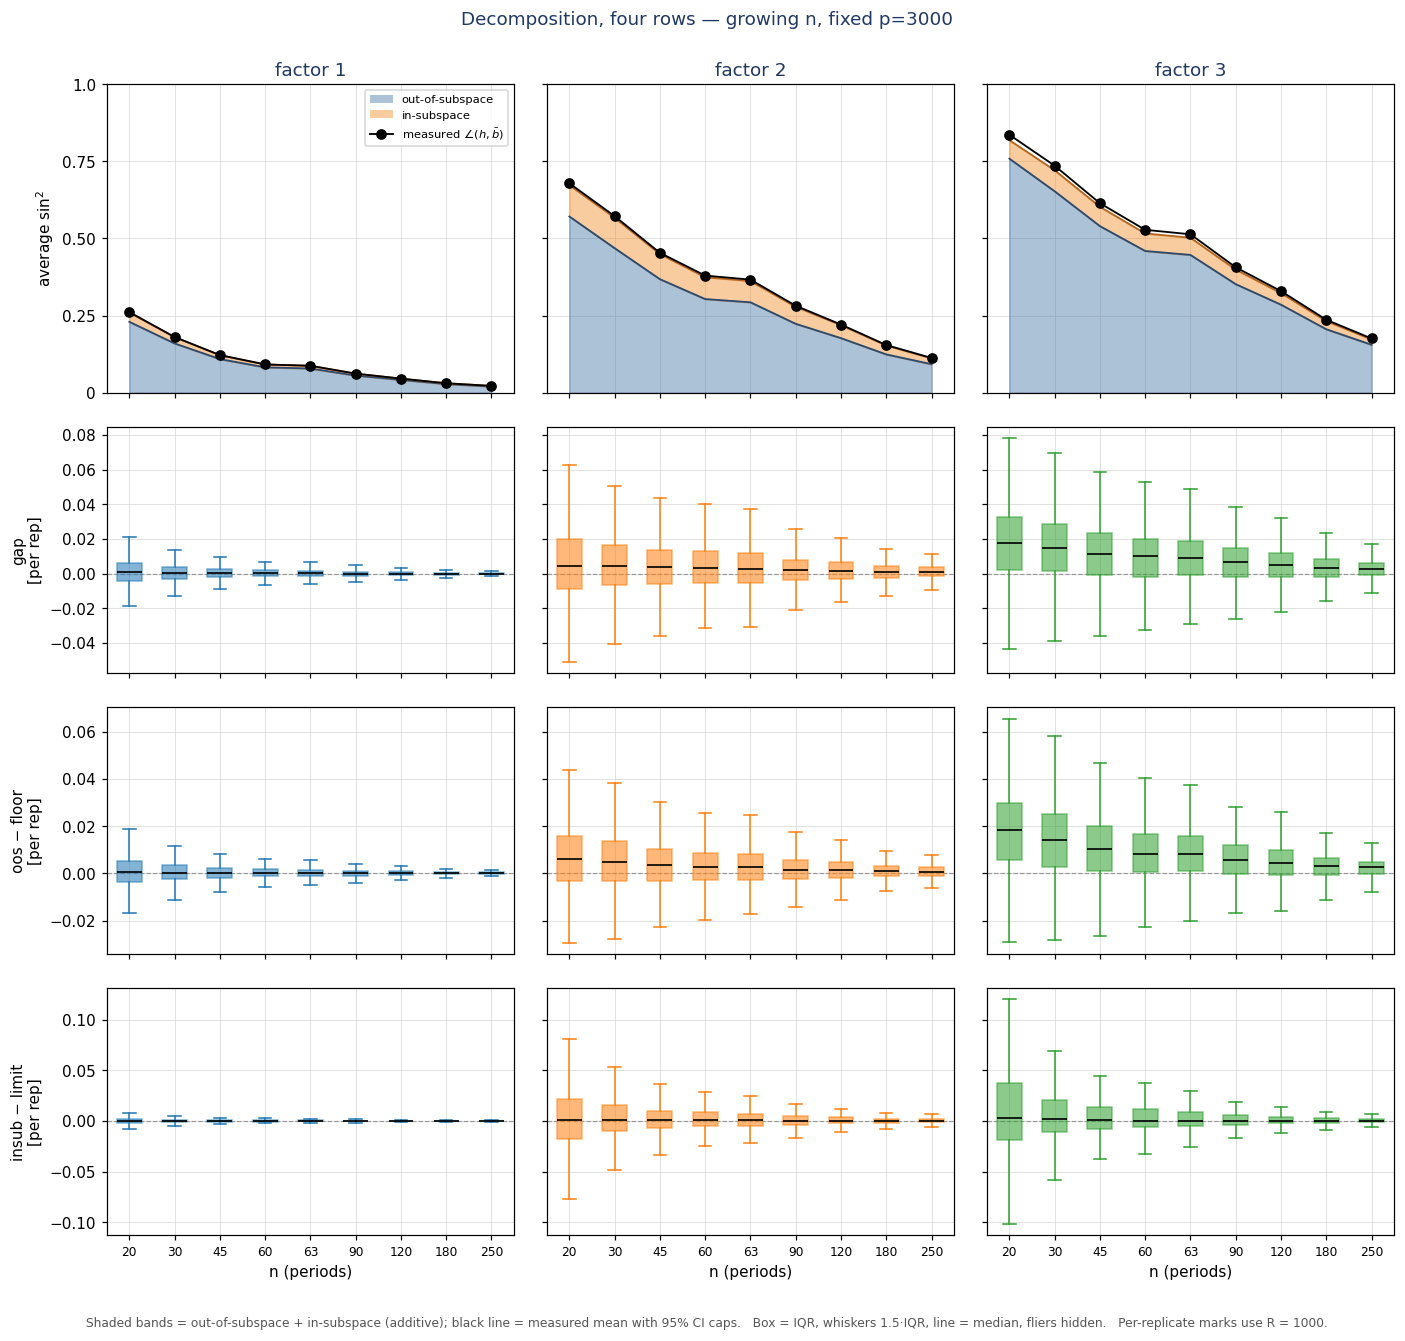

In [6]:
fig, _ = grid(df_n, "n",
              rows=[Row(BandStack(labels=("out-of-subspace", "in-subspace",
                                          r"measured $\angle(h,\bar b)$")),
                        ylabel=r"average $\sin^2$", ylim=(0, 1),
                        yticks=THEME.sin2_ticks, height=1.0),
                    Row(BoxDist("gap"), ylabel="gap\n[per rep]"),
                    Row(BoxDist("oos_gap"), ylabel="oos − floor\n[per rep]"),
                    Row(BoxDist("diff_in_rot"), ylabel="insub − limit\n[per rep]")],
              suptitle="Decomposition, four rows — growing n, fixed p=3000")
show(fig)

## 6 — Levels without a theory reference

For a quantity that has no limit to compare against (a *level*, not a difference),
`QuantileBand` is the honest top row: Q1–Q3 band + median, with the mean ± CI on top so
the skew is visible rather than hidden. Violin row below shows the full shape.

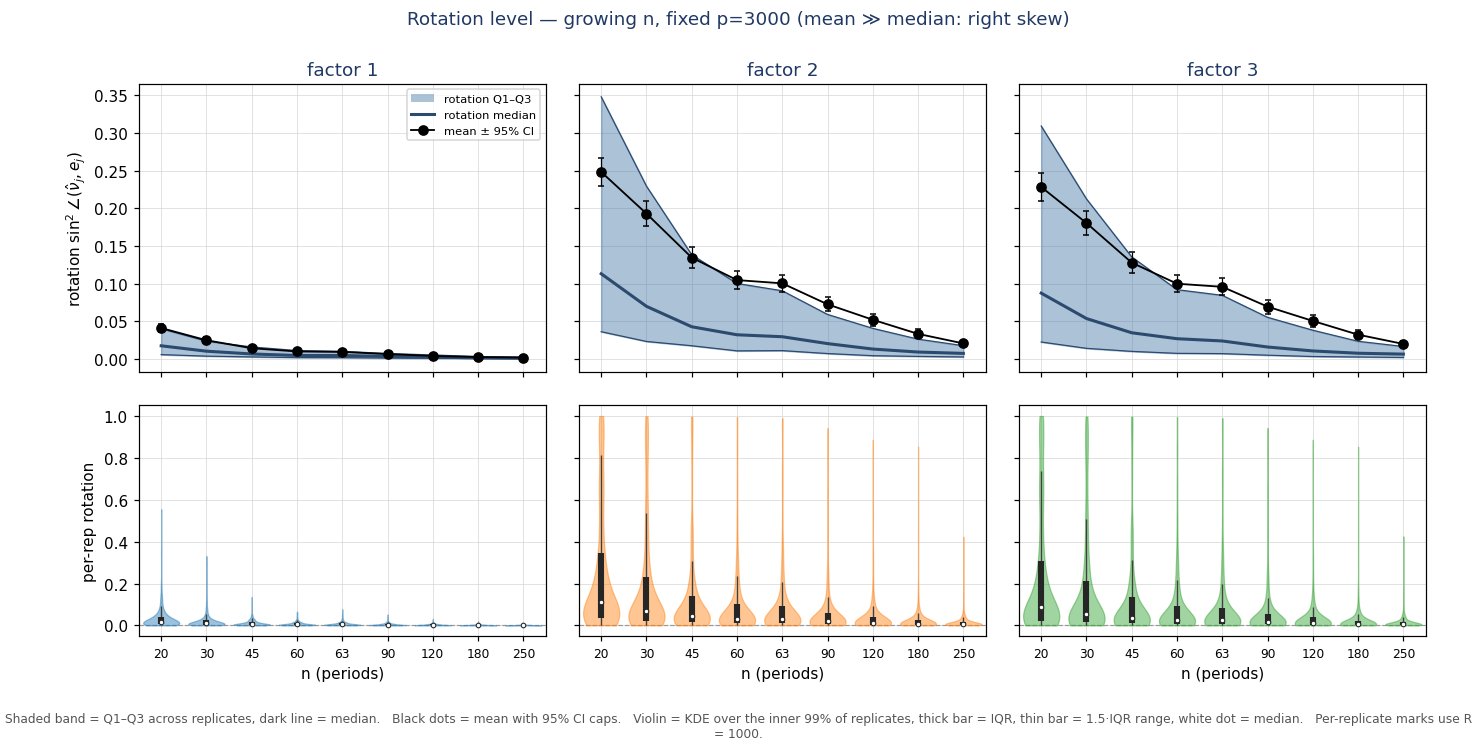

In [7]:
fig, _ = grid(df_n, "n",
              rows=[Row([QuantileBand("rotation", label="rotation"),
                         MeanCI("rotation", label="mean ± 95% CI")],
                        ylabel=r"rotation $\sin^2\angle(\hat\nu_j, e_j)$", height=1.0),
                    Row(ViolinDist("rotation"), ylabel="per-rep rotation")],
              suptitle="Rotation level — growing n, fixed p=3000 (mean ≫ median: right skew)")
show(fig)

## 7 — Extending: a custom mark

A mark is any object with `.draw(ax, ax_spec, sub, j_idx, theme)`, a `.caption`, and
`.legend_handles(theme)`. Here a tail-percentile line — the mass the boxplots hide as
fliers, which in these sweeps is where the 2↔3 identification failures live.

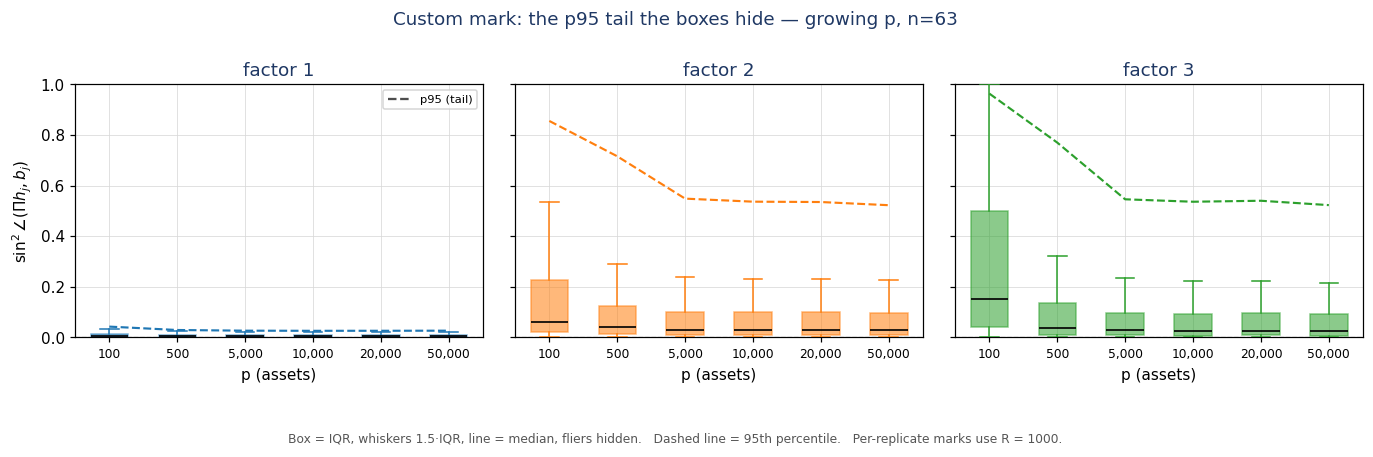

In [8]:
class TailLine:
    """Dashed per-factor line at the q-th percentile of the per-rep distribution."""

    def __init__(self, col, q=0.95):
        self.col, self.q = col, q
        self.caption = f"dashed line = {int(q * 100)}th percentile"

    def draw(self, ax, ax_spec, sub, j_idx, theme):
        tail = [np.quantile(a, self.q) for a in rep_dists(sub, ax_spec, self.col)]
        ax.plot(ax_spec.x, tail, "--", color=theme.factor_color(j_idx), lw=1.4, zorder=6)

    def legend_handles(self, theme):
        return [plt.Line2D([], [], ls="--", color="0.3",
                           label=f"p{int(self.q * 100)} (tail)")]


fig, _ = grid(df_p, "p",
              rows=[Row([BoxDist("sin2_in"), TailLine("sin2_in", q=0.95)],
                        ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
              sharey=True,
              suptitle="Custom mark: the p95 tail the boxes hide — growing p, n=63")
show(fig)

## 8 — Saving, themes, and the escape hatch

* **Saving** — pass `out_path` (extension optional) and `formats`; `grid` writes each and
  still returns `(fig, axes)` for further tweaking.
* **Theme** — pass `theme=Theme(...)` to restyle without touching call sites; the default
  matches the legacy `fl_graphics` look so figures sit side by side seamlessly.
* **Escape hatch** — the `draw_*` primitives (arrays in, artists out) work on any
  matplotlib `ax` for layouts `grid` doesn't cover.

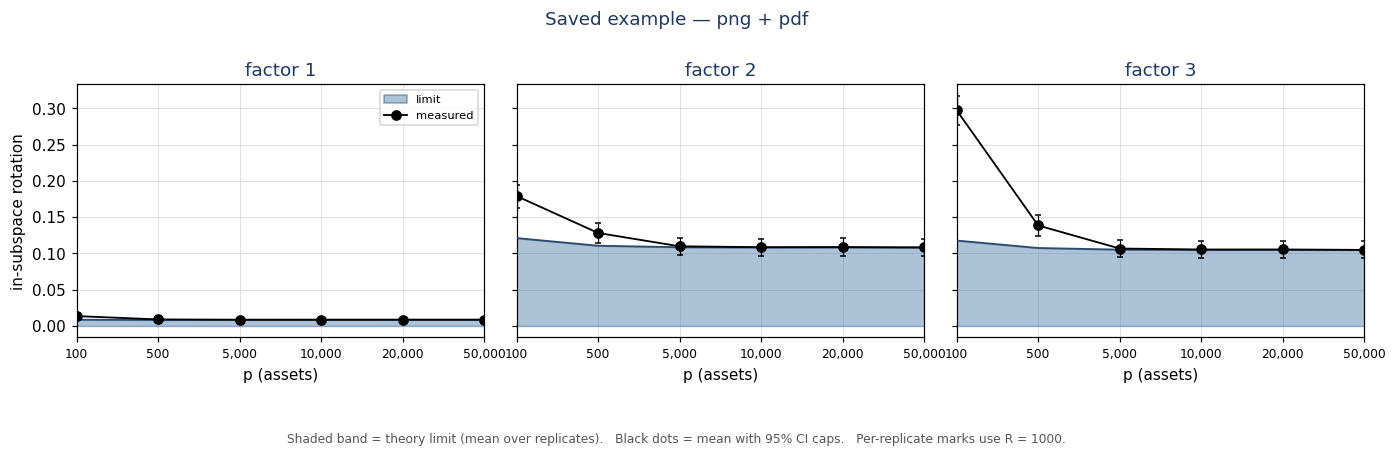

saved: ['demo_insub_rotation.pdf', 'demo_insub_rotation.png']


In [9]:
fig, axes = grid(df_p, "p",
                 rows=[Row([Band("rotation", label="limit"),
                            MeanCI("sin2_in", label="measured")],
                           ylabel="in-subspace rotation", height=1.0)],
                 suptitle="Saved example — png + pdf",
                 out_path=OUT_DIR / "demo_insub_rotation", formats=("png", "pdf"))
show(fig)
print("saved:", sorted(p.name for p in OUT_DIR.iterdir()))

## 9 — Disk density: direction clouds on the unit disk

`DiskDensity` renders per-replicate **direction projections** as a KDE heatmap on the unit
disk (ported from the `radial_graphs` prototype). Unlike the sweep marks it ignores the
categorical x-axis — each `Row` slices its own sweep value via `at={...}`, so a stack of
rows walks the sweep while columns stay factors.

Demo data: eigenvectors $\hat\nu_j$ of the $k\times k$ realized factor Gram, projected onto
the $(e_2, e_3)$ plane — factor 1 clusters at the origin (its mass is on $e_1$), factors
2–3 cluster at their own axes, and at small $n$ the 2↔3 identification failure appears as
an **arc of mass along the boundary** connecting the two axes (in-plane rotation preserves
unit norm, so misidentified replicates slide along the circle rather than detaching).

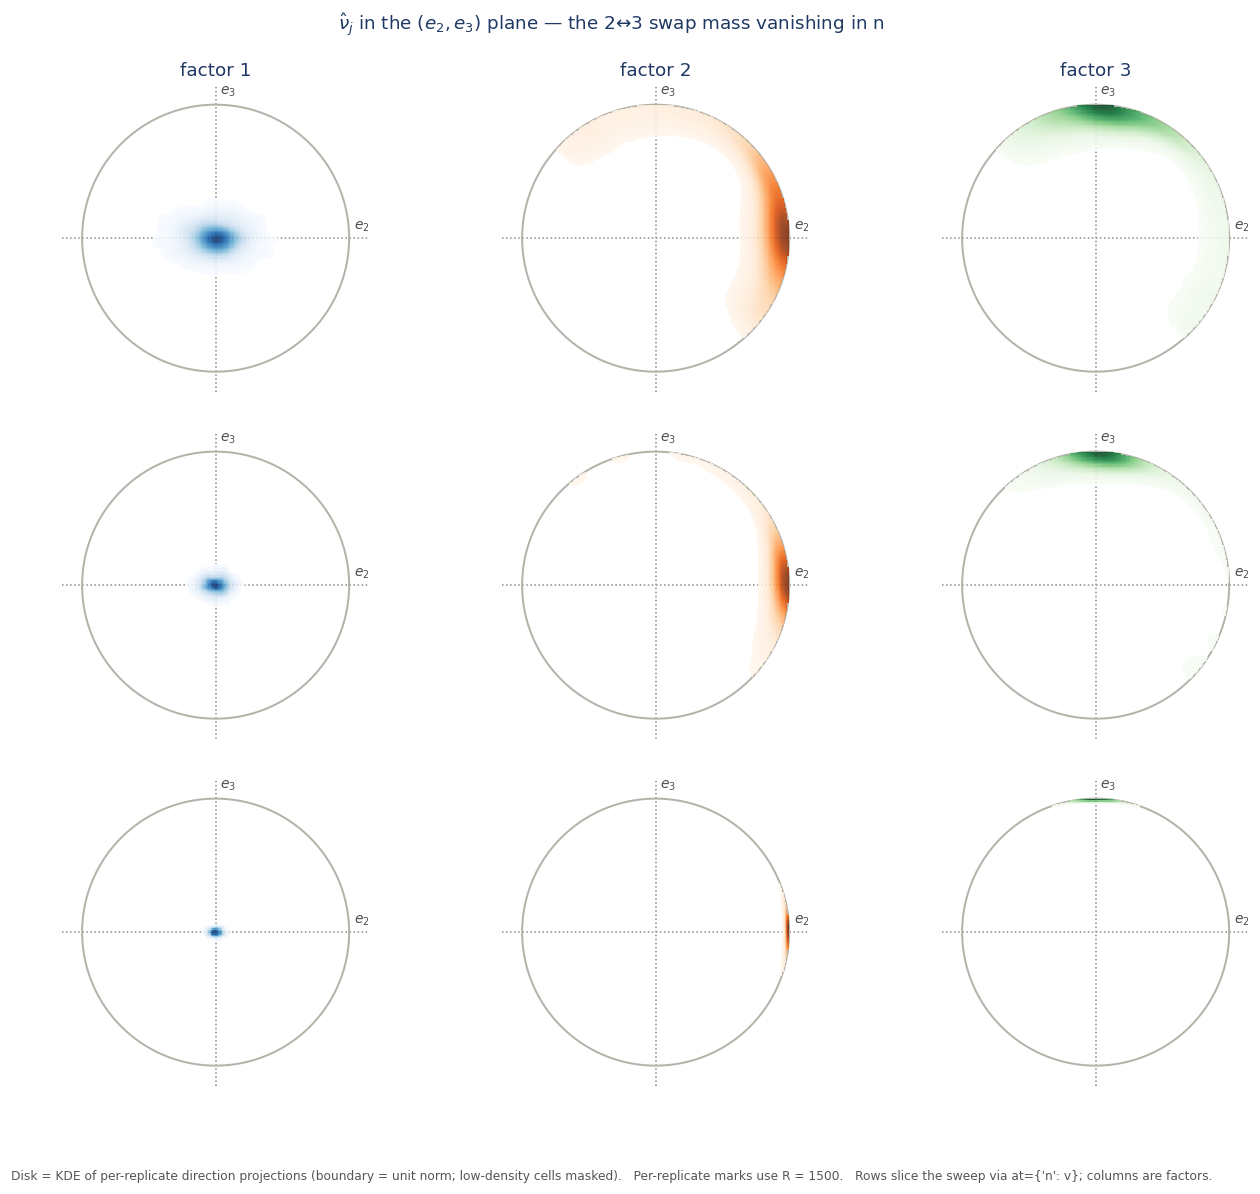

In [10]:
from fl_plot import DiskDensity

# k×k rotation sim (seconds): per-replicate eigenvectors of D̂, coords in the (e2, e3) plane.
_c = np.array([1.25, 1.0, 1.0]); _vols = np.array([0.16, 0.08, 0.06]); _ch = np.sqrt(_c)
_rng = np.random.default_rng(11)
_rows = []
for n in (20, 63, 250):
    for r in range(1500):
        F = _vols[:, None] * (_rng.standard_t(6, (3, n)) / np.sqrt(6 / 4))
        F = F - F.mean(1, keepdims=True)
        D = (_ch[:, None] * (F @ F.T / n)) * _ch[None, :]
        w, V = np.linalg.eigh(D)
        W = V[:, np.argsort(w)[::-1]]
        for j in range(3):
            v = W[:, j]
            v = v * np.sign(v[np.argmax(np.abs(v))])   # fold the arbitrary eigh sign
            _rows.append(dict(n=n, p=0, j=j + 1, rep=r, x2=v[1], x3=v[2]))
df_disk = pd.DataFrame(_rows)

fig, _ = grid(
    df_disk, "n",
    rows=[Row(DiskDensity("x2", "x3", at={"n": n}, labels=(r"$e_2$", r"$e_3$")),
              ylabel=f"n = {n}", height=1.0) for n in (20, 63, 250)],
    sharey=False,
    suptitle=r"$\hat\nu_j$ in the $(e_2, e_3)$ plane — the 2↔3 swap mass vanishing in n",
    caption_extra="Rows slice the sweep via at={'n': v}; columns are factors.")
show(fig)

---
### Cheatsheet

**Marks** — `BoxDist(col)` · `ViolinDist(col)` · `Band(col)` · `MeanCI(col)` ·
`BandStack(lower, upper, measured)` · `QuantileBand(col)` · `RefOverlay(col)` ·
`DiskDensity(xcol, ycol, at=...)` (all take `label=`; dist marks take `zero_line=`).

**Row** — `Row(mark_or_list, ylabel=..., height=..., ylim=..., yticks=...)`.

**grid** — `grid(df, key, rows, suptitle=, sharey="row"|True|False, out_path=,
formats=, caption_extra=, theme=)` → `(fig, axes)`.

**Data helpers** — `sweep_axis(df, key)`, `rep_dists(sub, ax_spec, col)`,
`summarize(sub, ax_spec, col)` (mean/sem/median/q1/q3 per swept value).